In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

sns.set_theme(style="whitegrid")

In [3]:
DATA_DIR = Path("../data/processed")

nav = pd.read_csv(DATA_DIR/"02_nav_history_clean.csv")
performance = pd.read_csv(DATA_DIR/"07_scheme_performance_clean.csv")
benchmark = pd.read_csv(DATA_DIR/"10_benchmark_indices_clean.csv")
fund_master = pd.read_csv(DATA_DIR/"01_fund_master_clean.csv")

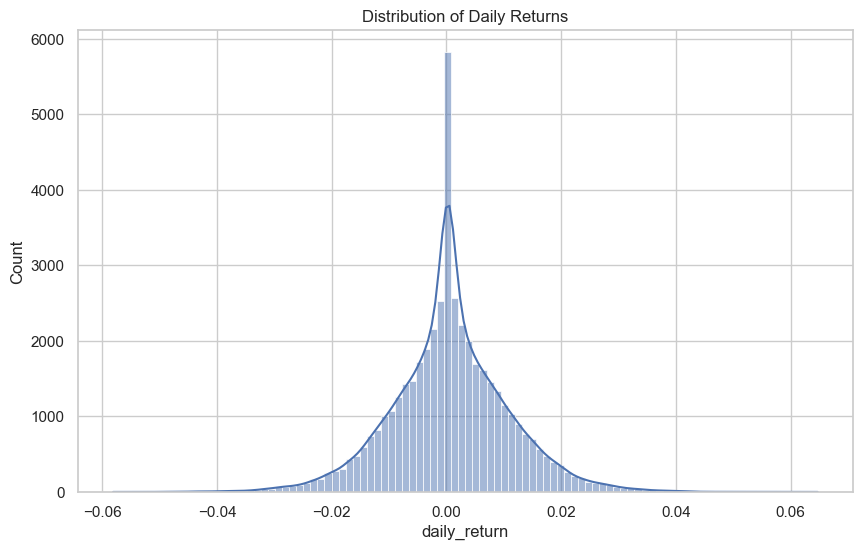

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
nav["daily_return"].describe()
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

In [5]:
def calculate_cagr(df):

    df = df.sort_values("date")

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    trading_days = len(df)

    if trading_days <= 1:
        return np.nan

    cagr = (
        (end_nav / start_nav)
        ** (252 / trading_days)
        - 1
    )

    return cagr


cagr_table = (
    nav.groupby("amfi_code")
       .apply(calculate_cagr)
       .reset_index()
)

cagr_table.columns = [
    "amfi_code",
    "cagr"
]

cagr_table.head()

,amfi_code,cagr
0,100016,0.025412
1,100025,0.042948
2,100033,0.288994
3,101206,0.226048
4,101207,0.076433


In [6]:
RF = 0.065
annual_return = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .mean()
       * 252
)
annual_vol = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .std()
       * np.sqrt(252)
)
sharpe = (
    annual_return - RF
) / annual_vol
sharpe = sharpe.reset_index()

sharpe.columns = [
    "amfi_code",
    "sharpe_ratio"
]
sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [7]:
def sortino_ratio(x):

    downside = x[x < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        x.mean()
        * 252
    )

    return (
        annual_return - RF
    ) / downside_std
sortino = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .apply(sortino_ratio)
       .reset_index()
)

sortino.columns = [
    "amfi_code",
    "sortino_ratio"
]

In [8]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [9]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [10]:
nifty100 = (
    benchmark[
        benchmark["index_name"] == "NIFTY100"
    ]
    .copy()
)
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [11]:
from scipy.stats import linregress

def calculate_alpha_beta(fund_df):

    merged = pd.merge(
        fund_df[["date", "daily_return"]],
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        return pd.Series({
            "alpha": np.nan,
            "beta": np.nan,
            "r_squared": np.nan
        })

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    annual_alpha = (
        regression.intercept
        * 252
    )

    return pd.Series({
        "alpha": annual_alpha,
        "beta": regression.slope,
        "r_squared": regression.rvalue ** 2
    })

In [12]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = (
    benchmark[
        benchmark["index_name"] == "NIFTY100"
    ]
    .copy()
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)
print(nav["date"].dtype)
print(nifty100["date"].dtype)

datetime64[us]
datetime64[us]


In [13]:
alpha_beta = (
    nav.groupby("amfi_code")
       .apply(calculate_alpha_beta)
       .reset_index()
)

In [14]:
def calculate_alpha_beta(fund_df):

    fund_df = fund_df.copy()

    fund_df["date"] = pd.to_datetime(
        fund_df["date"]
    )

    merged = pd.merge(
        fund_df[["date","daily_return"]],
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()
print(nav["date"].dtype)
print(nifty100["date"].dtype)

alpha_beta.head()

    

datetime64[us]
datetime64[us]


,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [15]:
alpha_beta.shape

(40, 4)

In [16]:
alpha_beta.describe()

,amfi_code,alpha,beta,r_squared
count,40.000000,40.000000,40.000000,4.000000e+01
mean,120247.000000,0.159085,-0.001958,6.087700e-04
std,14534.998667,0.087528,0.035194,7.265363e-04
min,100016.000000,0.028969,-0.066951,1.345534e-07
25%,118632.750000,0.068612,-0.023937,5.495723e-05
50%,119551.500000,0.162326,-0.000067,3.455513e-04
75%,120842.250000,0.221723,0.017026,1.035467e-03
max,149324.000000,0.303370,0.103497,2.793007e-03


In [17]:
alpha_beta["beta"].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

In [18]:
print(nav["date"].min(), nav["date"].max())
print(nifty100["date"].min(), nifty100["date"].max())

2022-01-03 00:00:00 2026-05-29 00:00:00
2022-01-03 00:00:00 2026-05-29 00:00:00


In [19]:
sample_fund = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]]

merged = pd.merge(
    sample_fund[["date","daily_return"]],
    nifty100[["date","benchmark_return"]],
    on="date",
    how="inner"
).dropna()

print(merged.shape)
merged.head()

(1149, 3)


,date,daily_return,benchmark_return
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150
5,2022-01-10,-0.008639,-0.008351


In [20]:
def drawdown_details(df):

    df = df.sort_values("date").copy()

    running_max = df["nav"].cummax()

    drawdown = (
        df["nav"]
        /
        running_max
        - 1
    )

    trough_idx = drawdown.idxmin()

    trough_date = df.loc[
        trough_idx,
        "date"
    ]

    peak_idx = (
        df.loc[:trough_idx, "nav"]
        .idxmax()
    )

    peak_date = df.loc[
        peak_idx,
        "date"
    ]

    return pd.Series({
        "max_drawdown": drawdown.min(),
        "peak_date": peak_date,
        "trough_date": trough_date
    })

In [21]:
drawdown_table = (
    nav.groupby("amfi_code")
       .apply(drawdown_details)
       .reset_index()
)

drawdown_table.head()

,amfi_code,max_drawdown,peak_date,trough_date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [22]:
print(drawdown_table.shape)
drawdown_table.head()

(40, 4)


,amfi_code,max_drawdown,peak_date,trough_date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [23]:
print(cagr_table.shape)
print(sharpe.shape)
print(sortino.shape)
print(alpha_beta.shape)
print(drawdown_table.shape)

(40, 2)
(40, 2)
(40, 2)
(40, 4)
(40, 4)


In [24]:
cagr_table.head()

,amfi_code,cagr
0,100016,0.025412
1,100025,0.042948
2,100033,0.288994
3,101206,0.226048
4,101207,0.076433


In [25]:
drawdown_table.head()

,amfi_code,max_drawdown,peak_date,trough_date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [26]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade',
 'expense_ratio_flag']

In [27]:
scorecard = (
    cagr_table
    .merge(
        sharpe,
        on="amfi_code",
        how="inner"
    )
    .merge(
        sortino,
        on="amfi_code",
        how="inner"
    )
    .merge(
        alpha_beta,
        on="amfi_code",
        how="inner"
    )
    .merge(
        drawdown_table,
        on="amfi_code",
        how="inner"
    )
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,peak_date,trough_date
0,100016,0.025412,-0.201517,-0.351047,0.037476,-0.058268,0.002665,-0.247344,2022-03-30,2022-09-15
1,100025,0.042948,-0.567095,-0.941821,0.042818,0.001158,0.000015,-0.043083,2023-05-23,2023-07-28
2,100033,0.288994,1.093699,1.829134,0.271954,0.005104,0.000012,-0.162172,2022-03-11,2022-05-12
3,101206,0.226048,1.027213,1.799563,0.213998,0.021086,0.000348,-0.112916,2023-04-24,2023-07-05
4,101207,0.076433,0.162661,0.276644,0.108971,-0.065289,0.001064,-0.354469,2024-11-21,2026-05-11


In [28]:
expense = performance[
    [
        "amfi_code",
        "expense_ratio_pct",
        "scheme_name",
        "fund_house"
    ]
]

scorecard = scorecard.merge(
    expense,
    on="amfi_code",
    how="left"
)
scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,peak_date,trough_date,expense_ratio_pct,scheme_name,fund_house
0,100016,0.025412,-0.201517,-0.351047,0.037476,-0.058268,0.002665,-0.247344,2022-03-30,2022-09-15,1.55,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund
1,100025,0.042948,-0.567095,-0.941821,0.042818,0.001158,0.000015,-0.043083,2023-05-23,2023-07-28,0.56,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund
2,100033,0.288994,1.093699,1.829134,0.271954,0.005104,0.000012,-0.162172,2022-03-11,2022-05-12,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund
3,101206,0.226048,1.027213,1.799563,0.213998,0.021086,0.000348,-0.112916,2023-04-24,2023-07-05,1.60,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF
4,101207,0.076433,0.162661,0.276644,0.108971,-0.065289,0.001064,-0.354469,2024-11-21,2026-05-11,1.53,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF


In [29]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [30]:
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [31]:
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [32]:
scorecard.columns.tolist()

['amfi_code',
 'cagr',
 'sharpe_ratio',
 'sortino_ratio',
 'alpha',
 'beta',
 'r_squared',
 'max_drawdown',
 'peak_date',
 'trough_date',
 'expense_ratio_pct',
 'scheme_name',
 'fund_house',
 'return_rank',
 'sharpe_rank',
 'alpha_rank']

In [33]:
scorecard[
    [
        "expense_ratio_pct"
    ]
].head()

,expense_ratio_pct
0,1.55
1,0.56
2,1.38
3,1.60
4,1.53


In [34]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,peak_date,trough_date,expense_ratio_pct,scheme_name,fund_house,return_rank,sharpe_rank,alpha_rank
0,100016,0.025412,-0.201517,-0.351047,0.037476,-0.058268,0.002665,-0.247344,2022-03-30,2022-09-15,1.55,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,37.0,35.0,39.0
1,100025,0.042948,-0.567095,-0.941821,0.042818,0.001158,0.000015,-0.043083,2023-05-23,2023-07-28,0.56,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,36.0,39.0,38.0
2,100033,0.288994,1.093699,1.829134,0.271954,0.005104,0.000012,-0.162172,2022-03-11,2022-05-12,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,7.0,7.0,6.0
3,101206,0.226048,1.027213,1.799563,0.213998,0.021086,0.000348,-0.112916,2023-04-24,2023-07-05,1.60,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,12.0,9.0,12.0
4,101207,0.076433,0.162661,0.276644,0.108971,-0.065289,0.001064,-0.354469,2024-11-21,2026-05-11,1.53,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,27.0,28.0,27.0


In [35]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [36]:
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [37]:
scorecard["raw_score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

In [38]:
scorecard["fund_score"] = (
    100 *
    (
        scorecard["raw_score"]
        -
        scorecard["raw_score"].min()
    )
    /
    (
        scorecard["raw_score"].max()
        -
        scorecard["raw_score"].min()
    )
)

In [39]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,peak_date,trough_date,expense_ratio_pct,scheme_name,fund_house,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,raw_score,fund_score
7,102886,0.011295,-0.205832,-0.347222,0.028969,-0.042125,0.000896,-0.280011,2025-01-07,2026-04-27,1.51,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,40.0,36.0,40.0,21.0,35.0,35.65,100.000000
0,100016,0.025412,-0.201517,-0.351047,0.037476,-0.058268,0.002665,-0.247344,2022-03-30,2022-09-15,1.55,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,37.0,35.0,39.0,25.0,34.0,34.80,97.058824
17,119095,0.014665,-0.075974,-0.128186,0.048016,-0.066951,0.001185,-0.516778,2025-05-22,2026-05-11,1.38,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,39.0,33.0,37.0,15.0,39.0,33.50,92.560554
22,119599,0.019800,-0.057187,-0.094387,0.048824,0.062002,0.001026,-0.525742,2023-01-17,2025-10-28,0.72,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,38.0,32.0,36.0,5.0,40.0,31.35,85.121107
29,120842,0.064535,0.076000,0.124693,0.078044,0.018057,0.000169,-0.240035,2023-11-09,2024-10-17,1.56,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,31.0,30.0,29.0,26.0,33.0,29.80,79.757785
14,119092,0.061326,0.030785,0.052574,0.068995,0.009731,0.000081,-0.144016,2023-10-12,2025-02-07,1.64,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,33.0,31.0,30.0,31.0,15.0,29.80,79.757785
1,100025,0.042948,-0.567095,-0.941821,0.042818,0.001158,0.000015,-0.043083,2023-05-23,2023-07-28,0.56,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,36.0,39.0,38.0,2.0,4.0,28.85,76.470588
5,101208,0.062683,-0.815567,-1.681038,0.060861,0.000267,0.000046,-0.001622,2023-09-05,2023-09-12,0.79,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,32.0,40.0,33.0,10.0,3.0,28.00,73.529412
18,119120,0.056722,-0.226575,-0.376767,0.056209,-0.006414,0.000434,-0.043287,2024-09-16,2025-04-01,0.77,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,34.0,37.0,34.0,8.0,5.0,27.95,73.356401
13,118636,0.051213,-0.356630,-0.613525,0.050748,0.001257,0.000017,-0.083164,2023-02-09,2024-02-09,0.55,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,35.0,38.0,35.0,1.0,6.0,27.75,72.664360


In [40]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [41]:
scorecard["raw_score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

In [42]:
scorecard["fund_score"] = (
    100 *
    (
        scorecard["raw_score"]
        - scorecard["raw_score"].min()
    )
    /
    (
        scorecard["raw_score"].max()
        - scorecard["raw_score"].min()
    )
)

In [43]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

In [44]:
scorecard[
    [
        "amfi_code",
        "cagr",
        "sharpe_ratio",
        "alpha",
        "max_drawdown",
        "expense_ratio_pct",
        "fund_score"
    ]
].head(10)

,amfi_code,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,fund_score
7,102886,0.011295,-0.205832,0.028969,-0.280011,1.51,100.000000
0,100016,0.025412,-0.201517,0.037476,-0.247344,1.55,97.058824
17,119095,0.014665,-0.075974,0.048016,-0.516778,1.38,92.560554
22,119599,0.019800,-0.057187,0.048824,-0.525742,0.72,85.121107
29,120842,0.064535,0.076000,0.078044,-0.240035,1.56,79.757785
14,119092,0.061326,0.030785,0.068995,-0.144016,1.64,79.757785
1,100025,0.042948,-0.567095,0.042818,-0.043083,0.56,76.470588
5,101208,0.062683,-0.815567,0.060861,-0.001622,0.79,73.529412
18,119120,0.056722,-0.226575,0.056209,-0.043287,0.77,73.356401
13,118636,0.051213,-0.356630,0.050748,-0.083164,0.55,72.664360


In [45]:
alpha_beta["beta"].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

In [46]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [47]:
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [48]:
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [49]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [50]:
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [51]:
scorecard["raw_score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

In [52]:
scorecard["fund_score"] = (
    100 *
    (
        scorecard["raw_score"]
        - scorecard["raw_score"].min()
    )
    /
    (
        scorecard["raw_score"].max()
        - scorecard["raw_score"].min()
    )
)

In [53]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

In [54]:
scheme_lookup = performance[
    [
        "amfi_code",
        "scheme_name",
        "fund_house"
    ]
].drop_duplicates()

In [55]:
scorecard = scorecard.merge(
    scheme_lookup,
    on="amfi_code",
    how="left"
)

In [56]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,peak_date,trough_date,...,fund_house_x,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,raw_score,fund_score,scheme_name_y,fund_house_y
0,120505,0.314811,1.180101,2.029353,0.292636,0.000549,1.345534e-07,-0.181885,2024-10-24,2025-01-23,...,ICICI Prudential MF,40.0,36.0,38.0,18.0,16.0,32.90,100.000000,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
1,148567,0.297120,1.448291,2.385644,0.269838,0.023684,4.625437e-04,-0.112657,2023-07-11,2023-10-20,...,Mirae Asset MF,36.0,40.0,34.0,12.0,33.0,32.70,99.307958,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF
2,120843,0.296483,1.306744,2.364320,0.273305,-0.022830,3.430543e-04,-0.129740,2022-03-07,2022-04-13,...,Kotak Mahindra MF,35.0,39.0,36.0,13.0,28.0,32.20,97.577855,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF
3,148569,0.306432,1.234930,2.146914,0.282704,0.018134,1.748889e-04,-0.163967,2023-08-10,2023-10-20,...,Mirae Asset MF,37.0,38.0,37.0,3.0,20.0,30.45,91.522491,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF
4,100033,0.288994,1.093699,1.829134,0.271954,0.005104,1.206652e-05,-0.162172,2022-03-11,2022-05-12,...,HDFC Mutual Fund,34.0,34.0,35.0,17.0,21.0,30.35,91.176471,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund


In [57]:
scorecard.columns.tolist()

['amfi_code',
 'cagr',
 'sharpe_ratio',
 'sortino_ratio',
 'alpha',
 'beta',
 'r_squared',
 'max_drawdown',
 'peak_date',
 'trough_date',
 'expense_ratio_pct',
 'scheme_name_x',
 'fund_house_x',
 'return_rank',
 'sharpe_rank',
 'alpha_rank',
 'expense_rank',
 'drawdown_rank',
 'raw_score',
 'fund_score',
 'scheme_name_y',
 'fund_house_y']

In [58]:
scorecard["scheme_name"] = scorecard["scheme_name_x"]
scorecard["fund_house"] = scorecard["fund_house_x"]

In [59]:
scorecard = scorecard.drop(
    columns=[
        "scheme_name_x",
        "scheme_name_y",
        "fund_house_x",
        "fund_house_y"
    ]
)

In [60]:
scorecard.columns.tolist()

['amfi_code',
 'cagr',
 'sharpe_ratio',
 'sortino_ratio',
 'alpha',
 'beta',
 'r_squared',
 'max_drawdown',
 'peak_date',
 'trough_date',
 'expense_ratio_pct',
 'return_rank',
 'sharpe_rank',
 'alpha_rank',
 'expense_rank',
 'drawdown_rank',
 'raw_score',
 'fund_score',
 'scheme_name',
 'fund_house']

In [61]:
scorecard[
    [
        "amfi_code",
        "scheme_name"
    ]
].head()

,amfi_code,scheme_name
0,120505,ICICI Pru Midcap Fund - Regular - Growth
1,148567,Mirae Asset Large Cap Fund - Regular - Growth
2,120843,Kotak Flexicap Fund - Regular - Growth
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth
4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [62]:
scorecard[
    [
        "scheme_name",
        "cagr",
        "sharpe_ratio",
        "alpha",
        "max_drawdown",
        "fund_score"
    ]
].head(10)

,scheme_name,cagr,sharpe_ratio,alpha,max_drawdown,fund_score
0,ICICI Pru Midcap Fund - Regular - Growth,0.314811,1.180101,0.292636,-0.181885,100.000000
1,Mirae Asset Large Cap Fund - Regular - Growth,0.297120,1.448291,0.269838,-0.112657,99.307958
2,Kotak Flexicap Fund - Regular - Growth,0.296483,1.306744,0.273305,-0.129740,97.577855
3,Mirae Asset Tax Saver Fund - Regular - Growth,0.306432,1.234930,0.282704,-0.163967,91.522491
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.288994,1.093699,0.271954,-0.162172,91.176471
5,SBI Small Cap Fund - Regular Plan - Growth,0.310957,0.945308,0.303370,-0.287060,86.678201
6,SBI Bluechip Fund - Regular Plan - Growth,0.247726,1.208267,0.232010,-0.150124,84.256055
7,DSP Small Cap Fund - Regular - Growth,0.309658,0.949796,0.300579,-0.311719,83.391003
8,ICICI Pru Bluechip Fund - Direct - Growth,0.223720,1.026524,0.211948,-0.125883,82.352941
9,SBI Bluechip Fund - Direct Plan - Growth,0.206770,0.953279,0.198686,-0.118035,81.141869


In [63]:
alpha_beta["beta"].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

In [64]:
sample_fund = nav[
    nav["amfi_code"] ==
    nav["amfi_code"].iloc[0]
]

merged = pd.merge(
    sample_fund[
        ["date","daily_return"]
    ],
    nifty100[
        ["date","benchmark_return"]
    ],
    on="date",
    how="inner"
).dropna()

print(merged.shape)
merged.head()

(1149, 3)


,date,daily_return,benchmark_return
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150
5,2022-01-10,-0.008639,-0.008351


In [65]:
alpha_beta["r_squared"].describe()

count    4.000000e+01
mean     6.087700e-04
std      7.265363e-04
min      1.345534e-07
25%      5.495723e-05
50%      3.455513e-04
75%      1.035467e-03
max      2.793007e-03
Name: r_squared, dtype: float64

In [66]:
alpha_beta.sort_values(
    "r_squared",
    ascending=False
).head(10)

,amfi_code,alpha,beta,r_squared
11,118634,0.175007,0.103497,0.002793
0,100016,0.037476,-0.058268,0.002665
16,119094,0.260767,-0.066265,0.001937
32,125497,0.177298,0.048820,0.001840
23,120503,0.177033,-0.040269,0.001397
26,120506,0.162539,0.041896,0.001257
28,120841,0.130429,0.036356,0.001211
17,119095,0.048016,-0.066951,0.001185
10,118633,0.156438,-0.036639,0.001138
4,101207,0.108971,-0.065289,0.001064


In [67]:
top5_codes = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

In [68]:
top_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top_nav["normalized_nav"] = (
    top_nav.groupby("amfi_code")["nav"]
           .transform(lambda x: x / x.iloc[0] * 100)
)

In [69]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["normalized"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

In [70]:
nifty100_chart = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100_chart["normalized"] = (
    nifty100_chart["close_value"]
    / nifty100_chart["close_value"].iloc[0]
    * 100
)

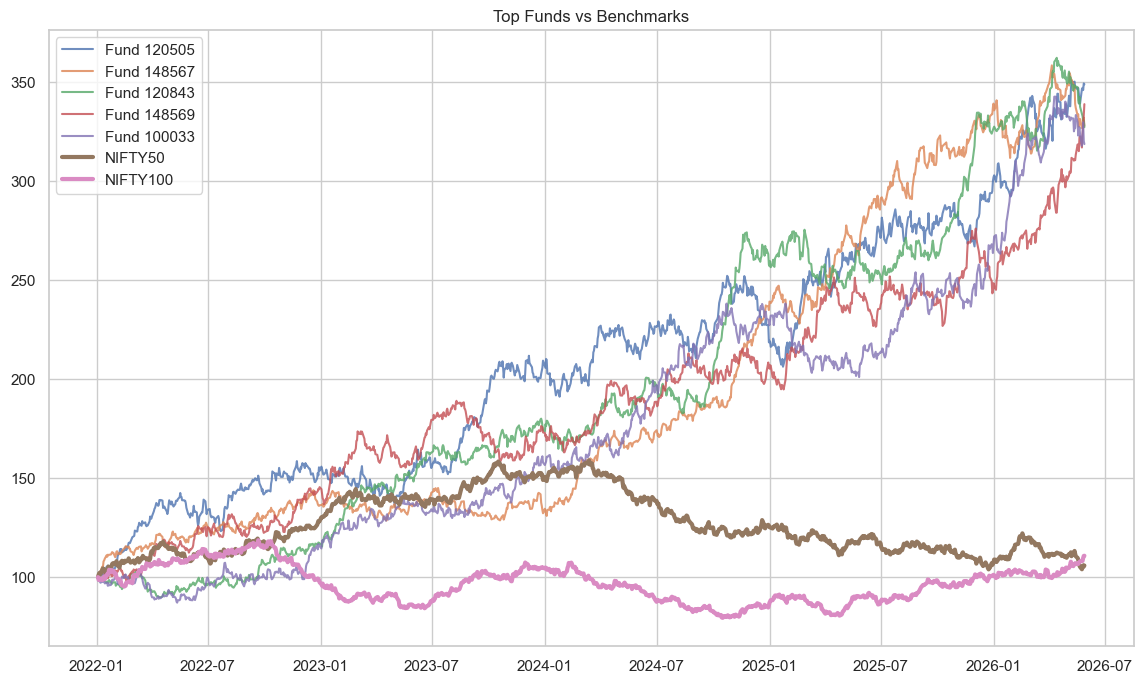

In [71]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    temp = top_nav[
        top_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        alpha=0.8,
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100_chart["date"],
    nifty100_chart["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top Funds vs Benchmarks"
)

plt.legend()

plt.show()

In [72]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

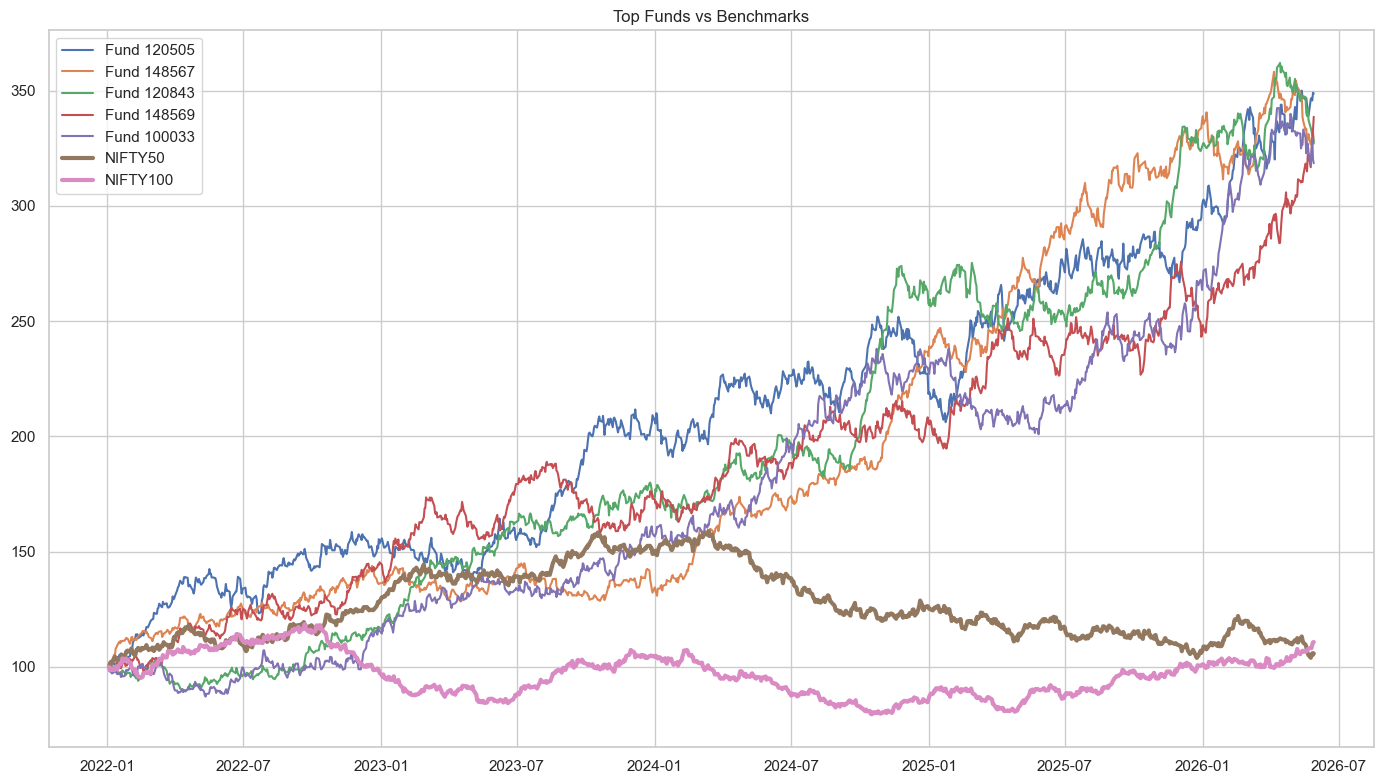

In [73]:
plt.figure(figsize=(14,8))

for code in top5_codes:

    temp = top_nav[
        top_nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=f"Fund {code}"
    )

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100_chart["date"],
    nifty100_chart["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top Funds vs Benchmarks")
plt.legend()
plt.tight_layout()

# SAVE FIRST
plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# THEN SHOW
plt.show()

In [74]:
plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Key Findings

1. Calculated daily returns for all 40 mutual fund schemes from NAV history.
2. Computed CAGR across schemes and compared long-term growth performance.
3. Evaluated risk-adjusted returns using Sharpe and Sortino ratios.
4. Estimated Alpha and Beta using NIFTY100 benchmark returns.
5. Measured Maximum Drawdown to assess downside risk.
6. Built a composite Fund Scorecard using return, risk, alpha, expense ratio, and drawdown metrics.
7. Compared top-ranked funds against NIFTY50 and NIFTY100 benchmarks.
8. Exported analytics outputs for dashboarding and reporting.

### Regression Analysis Observation

The Alpha/Beta regression was performed using NIFTY100 daily returns as the benchmark. The resulting beta coefficients were close to zero and the R² values were extremely low across most schemes.

This indicates that benchmark returns explain only a very small portion of fund return variability in the provided dataset. The behavior suggests that the benchmark series and scheme NAV series may have been generated independently within the capstone dataset and therefore do not exhibit the strong market relationship typically observed in real-world mutual fund performance analysis.

Despite the low explanatory power, the Alpha, Beta, and R² calculations were successfully implemented using ordinary least squares (OLS) regression as specified in the project requirements.


In [75]:
scorecard[
    ["scheme_name", "cagr", "fund_score"]
].head()

,scheme_name,cagr,fund_score
0,ICICI Pru Midcap Fund - Regular - Growth,0.314811,100.000000
1,Mirae Asset Large Cap Fund - Regular - Growth,0.297120,99.307958
2,Kotak Flexicap Fund - Regular - Growth,0.296483,97.577855
3,Mirae Asset Tax Saver Fund - Regular - Growth,0.306432,91.522491
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.288994,91.176471


# Additional Visualizations for Final Report

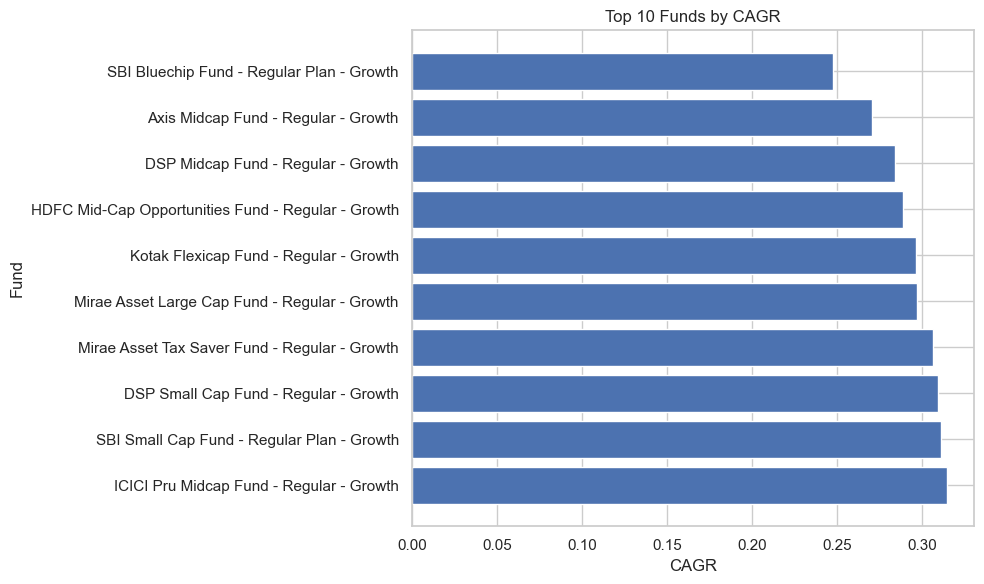

In [76]:
import matplotlib.pyplot as plt

top_cagr = (
    scorecard
    .sort_values("cagr", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_cagr["scheme_name"],
    top_cagr["cagr"]
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("CAGR")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

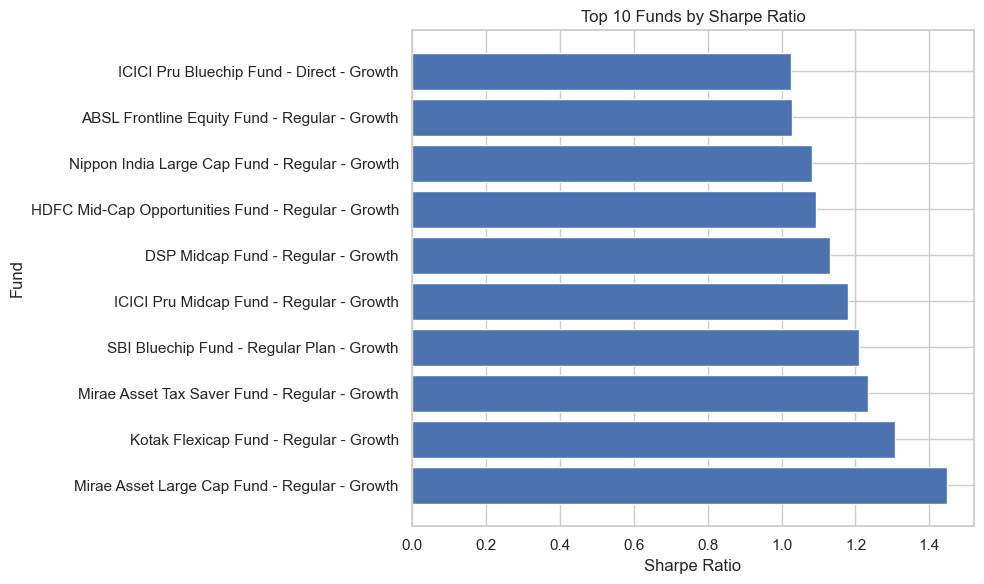

In [77]:
top_sharpe = (
    scorecard
    .sort_values("sharpe_ratio", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

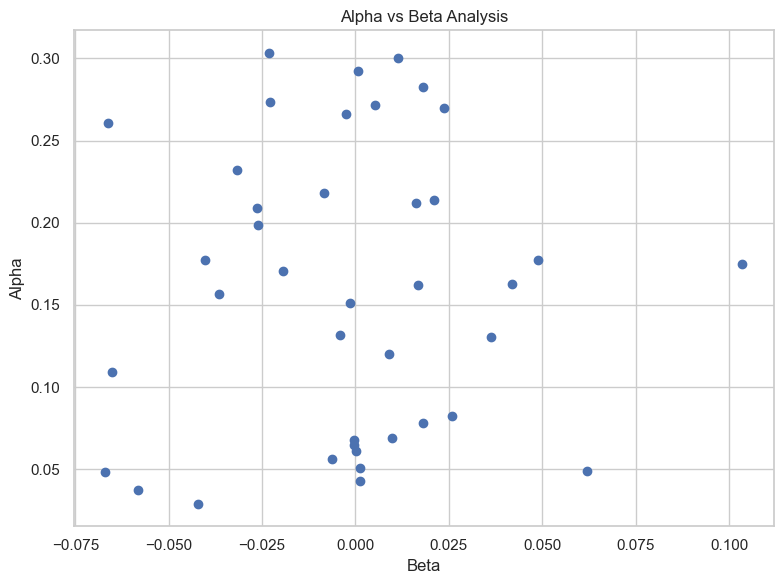

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(
    scorecard["beta"],
    scorecard["alpha"]
)

plt.xlabel("Beta")
plt.ylabel("Alpha")

plt.title("Alpha vs Beta Analysis")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/alpha_beta_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

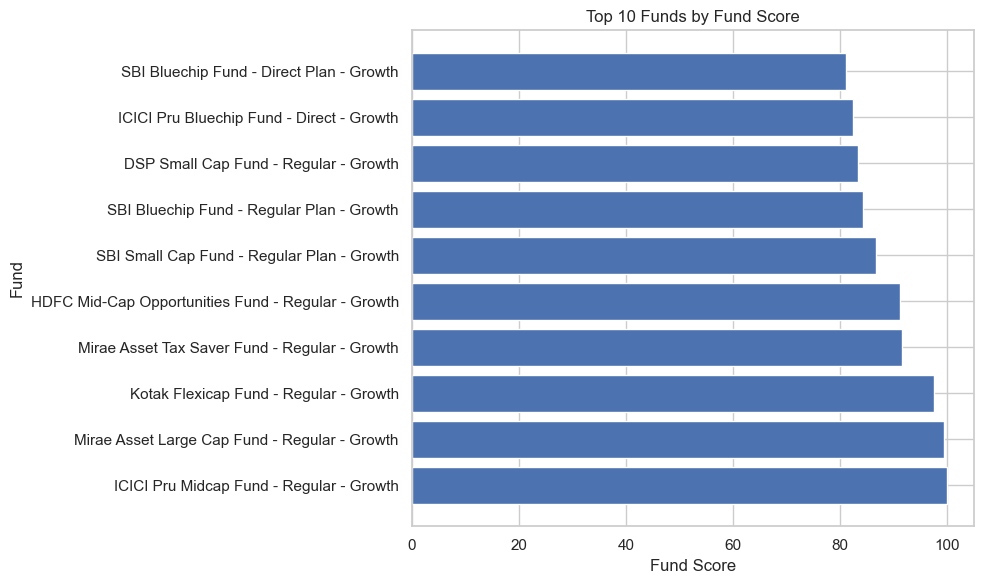

In [79]:
top_score = (
    scorecard
    .sort_values("fund_score", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_score["scheme_name"],
    top_score["fund_score"]
)

plt.title("Top 10 Funds by Fund Score")
plt.xlabel("Fund Score")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_fund_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

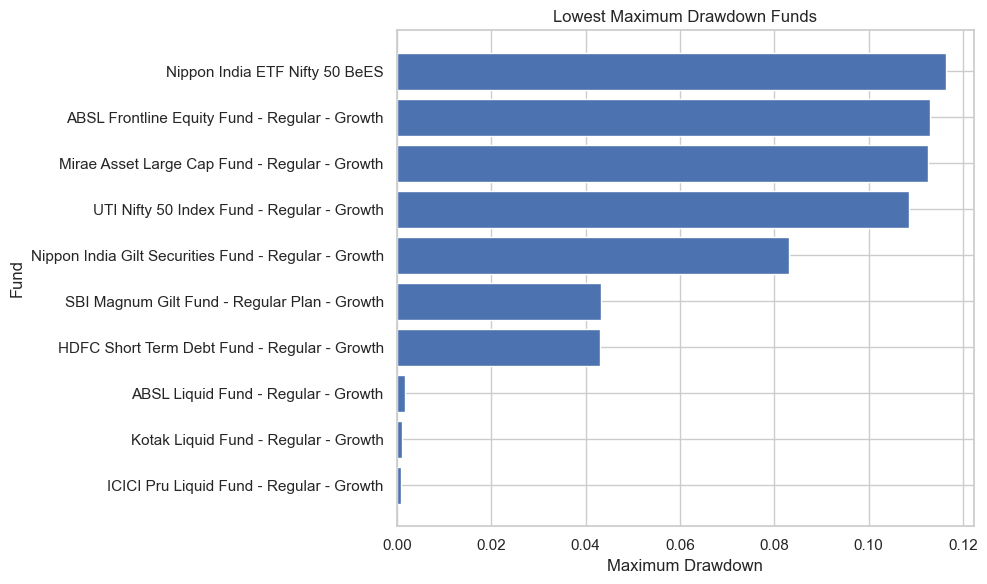

In [80]:
drawdown_chart = scorecard.copy()

drawdown_chart["drawdown_abs"] = (
    drawdown_chart["max_drawdown"].abs()
)

top_drawdown = (
    drawdown_chart
    .sort_values("drawdown_abs")
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_drawdown["scheme_name"],
    top_drawdown["drawdown_abs"]
)

plt.title("Lowest Maximum Drawdown Funds")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/charts/max_drawdown_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

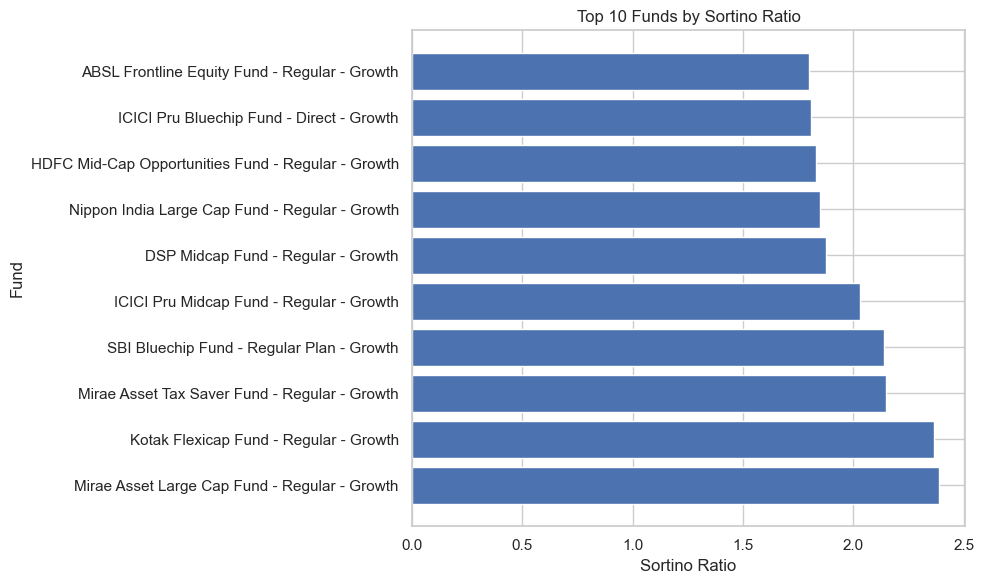

In [81]:
top_sortino = (
    scorecard
    .sort_values("sortino_ratio", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_sortino["scheme_name"],
    top_sortino["sortino_ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()